In [1]:
import glob
import numpy as np
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader
import torch

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [3]:
path = "/scratch/jz5952/FoV/dataset"
test_files = glob.glob(path + '/ChenYongting*.txt')
val_files = glob.glob(path + '/fupingyu*.txt') + glob.glob(path + '/GuoYushan*.txt')
train_files = glob.glob(path + '/*.txt')
other_files = glob.glob(path + '/intersection*.txt')+ glob.glob(path + '/original*.txt')+glob.glob(path + '/output*.txt')
train_files = list(filter(lambda i: i not in test_files and (i not in val_files and i not in other_files), train_files))

In [6]:
def get_sine_cosine(roll, pitch, yaw):

  r_sine = np.sin(roll*np.pi/180)
  r_cosine = np.cos(roll*np.pi/180)
  p_sine = np.sin(pitch*np.pi/180)
  p_cosine = np.cos(pitch*np.pi/180)
  y_sine = np.sin(yaw*np.pi/180)
  y_cosine = np.cos(yaw*np.pi/180)


  return pd.Series({'r_sine': r_sine, 'r_cosine': r_cosine, 'p_sine': p_sine, 'p_cosine': p_cosine, 'y_sine': y_sine, 'y_cosine': y_cosine})

# Creates dataframe for the file and resample
def createDataframe(f):
  df = pd.read_csv(f,sep=' ',header=None)
  df.columns = map(lambda x: x.replace(',',''), df.iloc[0])
  df = df.iloc[1:].astype(float)
  df = df.iloc[:,0:8]
  sine_cosine_df = df.apply(lambda row: get_sine_cosine(row['HeadRX'], row['HeadRY'], row['HeadRZ']), axis=1)
  df = pd.concat([df.iloc[:,0:5], sine_cosine_df], axis=1)
  df.index = pd.to_timedelta(df.index,unit='s')
  df = df.resample('200ms').interpolate('akima') # upsample by 5 --> 5 * 144 Hz
  df = df.resample('2400ms').first() # downsample by 12 --> (5 * 144) / 12 = 60 Hz
  df = df.reset_index(drop = True) # drop the timestamp index added
  regex_pattern = '.*Timer|.*Frame'
  filtered_columns = df.filter(regex=regex_pattern, axis=1)
  df = df.drop(columns=filtered_columns.columns)
  return df

# Creates input and output numpy array for a given dataframe, history_size, target_size and
# step size (in sec)
def multivariate_data(df, history_size = 10, target_size = 10, step = 15, window_size=60):
    data = []
    labels = []
    start_index = history_size * window_size
    end_index = len(df) - target_size * window_size

    for i in range(start_index, end_index, step):
        indices = range(i-history_size * window_size, i)
        data.append(df.iloc[indices])
        labels.append(df.iloc[i:i+target_size * window_size])

    return np.array(data), np.array(labels)

def normalizeData(files, history_size = 10, target_size = 10, step = 15, window_size=60):
  concatenatedDf = pd.DataFrame()
  for f in files:
    df = createDataframe(f)
    len(df)
    if len(df) < (history_size + target_size) * (window_size):
      continue
    concatenatedDf = pd.concat([concatenatedDf, df], axis=0)
  HeadX_mean = concatenatedDf['HeadX'].mean()
  HeadY_mean = concatenatedDf['HeadY'].mean()
  HeadZ_mean = concatenatedDf['HeadZ'].mean()
  HeadX_std = concatenatedDf['HeadX'].std()
  HeadY_std = concatenatedDf['HeadY'].std()
  HeadZ_std = concatenatedDf['HeadZ'].std()

  return HeadX_mean, HeadY_mean, HeadZ_mean, HeadX_std, HeadY_std, HeadZ_std

# Creates sequences for all the files
def createSequence(files, history_size = 10, target_size = 10, step = 15, window_size=60):
  x_list = []
  y_list = []

  HeadX_mean, HeadY_mean, HeadZ_mean, HeadX_std, HeadY_std, HeadZ_std = normalizeData(files, history_size, target_size, step, window_size)
  mean_std = np.array([HeadX_mean, HeadY_mean, HeadZ_mean, HeadX_std, HeadY_std, HeadZ_std])
  for f in files:
    print(f)
    df = createDataframe(f)
    len(df)
    if len(df) < (history_size + target_size) * (window_size):
      continue
    df['HeadX'] = (df['HeadX'] - HeadX_mean) / HeadX_std
    df['HeadY'] = (df['HeadY'] - HeadY_mean) / HeadY_std
    df['HeadZ'] = (df['HeadZ'] - HeadZ_mean) / HeadZ_std

    x_data, y_data = multivariate_data(df, history_size, target_size)
    x_list.append(x_data)
    y_list.append(y_data)

  x = np.concatenate(x_list, axis=0)
  y = np.concatenate(y_list, axis=0)
  return x, y, mean_std

In [8]:
history_size = 2
target_size = 2
x_train,y_train, mean_std_train = createSequence(train_files,history_size,target_size)
x_val,y_val, mean_std_val = createSequence(val_files,history_size,target_size)
x_test,y_test, mean_std_test = createSequence(test_files,history_size,target_size)

/scratch/jz5952/FoV/dataset/sulehan_sweep.txt
/scratch/jz5952/FoV/dataset/TuYuzhao_Pulling_trolley.txt
/scratch/jz5952/FoV/dataset/Guozhaonian_Pulling_trolley.txt
/scratch/jz5952/FoV/dataset/yuchen_chatting.txt
/scratch/jz5952/FoV/dataset/RenHongyu_cleaning_whiteboard.txt
/scratch/jz5952/FoV/dataset/LHJ_sweep.txt
/scratch/jz5952/FoV/dataset/HKY_news_interviewing.txt
/scratch/jz5952/FoV/dataset/FengXuanqi_Pulling_trolley.txt
/scratch/jz5952/FoV/dataset/Guozhaonian_News_interviewing.txt
/scratch/jz5952/FoV/dataset/liuxuya_cleaning_whiteboard.txt
/scratch/jz5952/FoV/dataset/liuxuya_News_interviewing.txt
/scratch/jz5952/FoV/dataset/huangrenyi_chatting.txt
/scratch/jz5952/FoV/dataset/WangYan_Pulling_trolley.txt
/scratch/jz5952/FoV/dataset/TuYuzhao_sweep.txt
/scratch/jz5952/FoV/dataset/liuxuya_chatting.txt
/scratch/jz5952/FoV/dataset/Sunqiran_Pulling_trolley.txt
/scratch/jz5952/FoV/dataset/HKY_presenting.txt
/scratch/jz5952/FoV/dataset/sulehan_presenting.txt
/scratch/jz5952/FoV/dataset/Sunqi

In [13]:
x_train

array([[[ 1.00138381e+00, -1.08857865e+00,  2.60085781e-01, ...,
         -5.51296444e-01,  2.70412084e-02,  9.99634320e-01],
        [ 1.00254854e+00, -1.08664168e+00,  2.61095622e-01, ...,
         -5.51460253e-01,  2.40392698e-02,  9.99710772e-01],
        [ 1.00419686e+00, -1.08385301e+00,  2.63367490e-01, ...,
         -5.47825626e-01,  2.06251429e-02,  9.99787188e-01],
        ...,
        [ 1.32063801e+00, -7.05775219e-01,  2.18966686e-01, ...,
         -9.40131577e-02, -6.06249641e-02,  9.98159614e-01],
        [ 1.32281608e+00, -6.99292537e-01,  2.17162777e-01, ...,
         -8.58344967e-02, -5.74431469e-02,  9.98348884e-01],
        [ 1.32503482e+00, -6.97273797e-01,  2.15844333e-01, ...,
         -8.39580023e-02, -5.90356799e-02,  9.98255783e-01]],

       [[ 1.02494843e+00, -1.06200850e+00,  2.39810436e-01, ...,
         -4.72267718e-01,  5.58226551e-02,  9.98440700e-01],
        [ 1.02336009e+00, -1.04703367e+00,  2.36678706e-01, ...,
         -4.61037082e-01,  5.91498296e

In [16]:
x_train.shape

(5956, 120, 9)

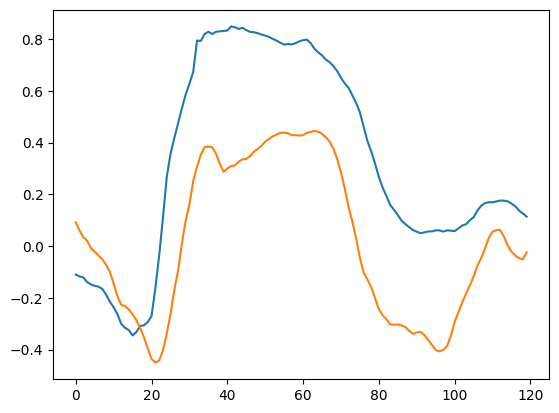

In [20]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_val[0,:,1])
plt.plot(y_val[0,:,1])
plt.show()

In [10]:
mean_std = np.concatenate((mean_std_train,mean_std_val,mean_std_test))
mean_std

array([-0.17538009,  1.54045129, -0.07789762,  0.64761491,  0.19281041,
        0.6331828 , -0.57218326,  1.49466578,  0.10119342,  0.57687788,
        0.04357762,  0.70488648, -0.32691124,  1.53392609,  0.16154999,
        0.44393889,  0.03929263,  0.39338548])

In [11]:
# save to csv file
np.savetxt(f'processed_data/x_train_{history_size}_{target_size}.csv', x_train.reshape((x_train.shape[0],-1)), delimiter=',')
np.savetxt(f'processed_data/y_train_{history_size}_{target_size}.csv', y_train.reshape((y_train.shape[0],-1)), delimiter=',')
np.savetxt(f'processed_data/x_val_{history_size}_{target_size}.csv', x_val.reshape((x_val.shape[0],-1)), delimiter=',')
np.savetxt(f'processed_data/y_val_{history_size}_{target_size}.csv', y_val.reshape((y_val.shape[0],-1)), delimiter=',')
np.savetxt(f'processed_data/x_test_{history_size}_{target_size}.csv', x_test.reshape((x_test.shape[0],-1)), delimiter=',')
np.savetxt(f'processed_data/y_test_{history_size}_{target_size}.csv', y_test.reshape((y_test.shape[0],-1)), delimiter=',')
np.savetxt(f'processed_data/xyz_mean_std_{history_size}_{target_size}.csv',mean_std)

In [9]:
class FoVDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x_data = x_data
        self.y_data = y_data

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        x = torch.tensor(self.x_data[idx])
        y = torch.tensor(self.y_data[idx])
        return x,y

In [10]:
train_data = FoVDataset(x_train, y_train)
val_data = FoVDataset(x_val, y_val)
test_data = FoVDataset(x_test, y_test)

In [11]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

In [12]:
train_data[0][0][0]

tensor([ 1.0564, -1.2644,  0.3604,  0.8053,  0.5928, -0.8343, -0.5513,  0.0270,
         0.9996], dtype=torch.float64)

In [1]:
x_train.shape[1]

NameError: name 'x_train' is not defined